# EDA — ArrowFin Trading Assessment Dataset

Exploring `accounts`, `traders`, `instruments`, `market_prices` and
`fills`. Reusable loading/profiling/merging functions live in this
`notebooks` package (`dataset_loading.py`, `frame_profiling.py`,
`account_trader_merge.py`, `column_glossary.py`) and are imported
below rather than redefined inline.

In [1]:
import pandas as pd

from trading_analysis.notebooks.account_trader_merge import (
    count_accounts_per_trader,
    merge_accounts_with_traders,
)
from trading_analysis.notebooks.column_glossary import glossary_table
from trading_analysis.notebooks.dataset_loading import load_trading_tables
from trading_analysis.notebooks.frame_profiling import (
    foreign_key_coverage,
    low_cardinality_value_counts,
    summarize_frame,
)

pd.set_option("display.max_columns", None)

tables = load_trading_tables()
accounts = tables["accounts"]
traders = tables["traders"]
instruments = tables["instruments"]
market_prices = tables["market_prices"]
fills = tables["fills"]
brokers = tables["brokers"]

{name: df.shape for name, df in tables.items()}

{'accounts': (54, 9),
 'traders': (48, 8),
 'instruments': (8, 8),
 'market_prices': (8, 3),
 'fills': (5146, 10),
 'brokers': (3, 5)}

In [2]:
summarize_frame(accounts)

,dtype,non_null_count,null_count,null_pct,n_unique
id,str,54,0,0.0,54
trader_id,str,54,0,0.0,48
account_number,str,54,0,0.0,54
account_type,str,54,0,0.0,5
balance,float64,54,0,0.0,8
buying_power,float64,54,0,0.0,7
max_position_size,int64,54,0,0.0,4
status,str,54,0,0.0,3
created_at,"datetime64[us, UTC]",54,0,0.0,50


In [3]:
summarize_frame(traders)

,dtype,non_null_count,null_count,null_pct,n_unique
id,str,48,0,0.0,48
broker_id,str,48,0,0.0,3
first_name,str,48,0,0.0,47
last_name,str,48,0,0.0,47
email,str,48,0,0.0,48
phone,str,48,0,0.0,48
kyc_status,str,48,0,0.0,1
created_at,"datetime64[us, UTC]",48,0,0.0,48


In [4]:
low_cardinality_value_counts(accounts)

{'account_type': account_type
 funded      34
 eval        10
 pro          8
 pro_plus     1
 demo         1
 Name: count, dtype: int64,
 'balance': balance
 25000.0     15
 100000.0    12
 50000.0     10
 75000.0      9
 150000.0     5
 18000.0      1
 0.0          1
 31500.0      1
 Name: count, dtype: int64,
 'buying_power': buying_power
 25000.0     14
 100000.0    12
 50000.0     10
 75000.0      9
 150000.0     5
 0.0          3
 18000.0      1
 Name: count, dtype: int64,
 'max_position_size': max_position_size
 5     44
 10     7
 8      2
 20     1
 Name: count, dtype: int64,
 'status': status
 active        52
 closed         1
 restricted     1
 Name: count, dtype: int64}

In [5]:
low_cardinality_value_counts(traders)

{'broker_id': broker_id
 BRK-ARWP    16
 BRK-SMPT    16
 BRK-MRDN    16
 Name: count, dtype: int64,
 'kyc_status': kyc_status
 verified    48
 Name: count, dtype: int64}

In [6]:
foreign_key_coverage(accounts, "trader_id", traders, "id")

{'orphaned_child_values': set(), 'unreferenced_parent_values': set()}

In [7]:
accounts_per_trader = count_accounts_per_trader(accounts)
accounts_per_trader.value_counts().sort_index().rename("n_traders")

account_count
1    43
2     4
3     1
Name: n_traders, dtype: int64

In [8]:
accounts_with_traders = merge_accounts_with_traders(accounts, traders)
accounts_with_traders.head()

,id_account,trader_id,account_number,account_type,balance,buying_power,max_position_size,status,created_at_account,id_trader,broker_id,first_name,last_name,email,phone,kyc_status,created_at_trader
0,ACC-2001,T-001,APX-300001,eval,100000.0,100000.0,10,active,2026-03-01 00:00:00+00:00,T-001,BRK-ARWP,Mateo,Herrera,mateo.herrera@gmail.com,+1-555-0100,verified,2026-02-01 00:00:00+00:00
1,ACC-2002,T-002,SMT-300002,eval,150000.0,150000.0,10,active,2026-03-02 00:00:00+00:00,T-002,BRK-SMPT,Sofia,Rossi,sofia.rossi@smptprop.example,+1-555-0101,verified,2026-02-02 00:00:00+00:00
2,ACC-2003,T-003,MRD-300003,funded,150000.0,150000.0,10,active,2026-03-03 00:00:00+00:00,T-003,BRK-MRDN,Lucas,Tanaka,lucas.tanaka@mrdnprop.example,+1-555-0102,verified,2026-02-03 00:00:00+00:00
3,ACC-2004,T-004,APX-300004,pro,100000.0,100000.0,10,active,2026-03-04 00:00:00+00:00,T-004,BRK-ARWP,Valentina,Novak,valentina.novak@gmail.com,+1-555-0103,verified,2026-02-04 00:00:00+00:00
4,ACC-2005,T-005,SMT-300005,funded,100000.0,100000.0,10,active,2026-03-05 00:00:00+00:00,T-005,BRK-SMPT,Andres,Silva,andres.silva@smptprop.example,+1-555-0104,verified,2026-02-05 00:00:00+00:00


In [9]:
glossary_table("instruments")

,column,meaning
0,symbol,"Futures contract ticker, e.g. ES, MES, NQ."
1,description,Human-readable name of the contract.
2,exchange,Exchange the contract trades on.
3,point_value_usd,"USD value of one full point of price movement,..."
4,tick_size,Smallest price increment the contract can move.
5,tick_value_usd,USD value of one tick move (tick_size * point_...
6,initial_margin_usd,Margin required to open one contract's position.
7,maintenance_margin_usd,Minimum margin to keep one contract's position...


In [10]:
instruments

,symbol,description,exchange,point_value_usd,tick_size,tick_value_usd,initial_margin_usd,maintenance_margin_usd
0,ES,E-mini S&P 500,CME,50,0.25000,12.50,13200,12000
1,MES,Micro E-mini S&P 500,CME,5,0.25000,1.25,1320,1200
2,NQ,E-mini Nasdaq-100,CME,20,0.25000,5.00,17600,16000
3,MNQ,Micro E-mini Nasdaq-100,CME,2,0.25000,0.50,1760,1600
4,CL,Crude Oil,NYMEX,1000,0.01000,10.00,6600,6000
5,MCL,Micro Crude Oil,NYMEX,100,0.01000,1.00,660,600
6,GC,Gold,COMEX,100,0.10000,10.00,11000,10000
7,6E,Euro FX,CME,125000,0.00005,6.25,2420,2200


In [11]:
glossary_table("market_prices").T.to_dict()

{0: {'column': 'symbol',
  'meaning': 'Instrument ticker; joins to instruments.symbol.'},
 1: {'column': 'mark_price',
  'meaning': 'Latest price used to value open positions for unrealized P&L as of the dataset cut.'},
 2: {'column': 'as_of',
  'meaning': 'Timestamp of the mark. Constant across rows: the dataset cut, 2026-08-25T14:30:00Z.'}}

In [12]:
market_prices.merge(instruments[["symbol", "point_value_usd"]], on="symbol")

,symbol,mark_price,as_of,point_value_usd
0,ES,5642.25000,2026-08-25 14:30:00+00:00,50
1,MES,5642.25000,2026-08-25 14:30:00+00:00,5
2,NQ,19845.50000,2026-08-25 14:30:00+00:00,20
3,MNQ,19845.50000,2026-08-25 14:30:00+00:00,2
4,CL,74.18000,2026-08-25 14:30:00+00:00,1000
5,MCL,74.18000,2026-08-25 14:30:00+00:00,100
6,GC,2488.30000,2026-08-25 14:30:00+00:00,100
7,6E,1.10425,2026-08-25 14:30:00+00:00,125000


In [13]:
glossary_table("fills")

,column,meaning
0,id,Unique identifier of this execution (fill).
1,account_id,Foreign key to accounts.id.
2,instrument_symbol,Foreign key to instruments.symbol.
3,side,Trade direction: BUY or SELL.
4,quantity,Number of contracts executed in this fill.
5,price,Execution price per contract for this fill.
6,filled_at,UTC ISO 8601 timestamp of the execution.
7,order_id,Groups fills belonging to one order. An order ...
8,liquidity,'maker' (this fill added resting liquidity to ...
9,commission_usd,"Commission charged for this fill, per contract..."


In [14]:
summarize_frame(fills)

,dtype,non_null_count,null_count,null_pct,n_unique
id,str,5146,0,0.0,5146
account_id,str,5146,0,0.0,53
instrument_symbol,str,5146,0,0.0,8
side,str,5146,0,0.0,2
quantity,int64,5146,0,0.0,14
price,float64,5146,0,0.0,1058
filled_at,"datetime64[us, UTC]",5146,0,0.0,5047
order_id,str,5146,0,0.0,4886
liquidity,str,5146,0,0.0,2
commission_usd,float64,5146,0,0.0,27


In [15]:
low_cardinality_value_counts(fills)

{'instrument_symbol': instrument_symbol
 MNQ    2210
 MES    1132
 6E      435
 GC      376
 MCL     368
 ES      339
 NQ      283
 CL        3
 Name: count, dtype: int64,
 'side': side
 BUY     2588
 SELL    2558
 Name: count, dtype: int64,
 'quantity': quantity
 2     1267
 3     1127
 4      838
 1      619
 5      538
 6      180
 7      144
 9      137
 8      133
 10     131
 12      21
 11       7
 13       2
 14       2
 Name: count, dtype: int64,
 'liquidity': liquidity
 taker    3443
 maker    1703
 Name: count, dtype: int64}

In [16]:
# Fills per order_id — most orders fill in one piece, some in several
fills.groupby("order_id").size().value_counts().sort_index().rename(
    "n_orders"
)

1    4626
2     260
Name: n_orders, dtype: int64

In [17]:
{
    "fills.instrument_symbol -> instruments.symbol": foreign_key_coverage(
        fills, "instrument_symbol", instruments, "symbol"
    ),
    "fills.account_id -> accounts.id": foreign_key_coverage(
        fills, "account_id", accounts, "id"
    ),
    "market_prices.symbol -> instruments.symbol": foreign_key_coverage(
        market_prices, "symbol", instruments, "symbol"
    ),
}

{'fills.instrument_symbol -> instruments.symbol': {'orphaned_child_values': set(),
  'unreferenced_parent_values': set()},
 'fills.account_id -> accounts.id': {'orphaned_child_values': set(),
  'unreferenced_parent_values': {'ACC-2047'}},
 'market_prices.symbol -> instruments.symbol': {'orphaned_child_values': set(),
  'unreferenced_parent_values': set()}}

**Observation:** `fills.account_id -> accounts.id` reports one
`unreferenced_parent_value`: `ACC-2047` has zero fills. That's a
real account with no trading history yet, not a data-quality bug —
consistent with the README's note that some accounts started very
recently.


I'll filter this dataset to only include accounts with at least one fill

## 3) `instruments`, `market_prices` and `fills`

These three tables describe futures contracts and their executions.
Column-by-column glossaries (`column_glossary.py`) below; a few
things worth knowing up front:

- **`instruments`** (8 rows) is the contract spec sheet: one row per
  tradable symbol (`ES`, `MES`, `NQ`, `MNQ`, `CL`, `MCL`, `GC`, `6E`).
  The critical column is `point_value_usd` — it converts a price move
  into a dollar P&L, and it is *not* comparable across a
  full-size/micro pair: `NQ` and `MNQ` track the same index but
  `point_value_usd` is 20 vs. 2 (10x), same for `ES`/`MES` (50 vs. 5)
  and `CL`/`MCL`. Mixing them up silently inflates or deflates P&L
  by 10x.
- **`market_prices`** (8 rows) is a single snapshot mark per symbol
  at the dataset cut (`as_of` is constant), used to value any
  position still open at that moment — not every fill has been
  closed out.
- **`fills`** (5,146 rows) is the execution log: each row is one
  partial or full execution. Fills sharing an `order_id` belong to
  one order, not separate trades (see the distribution below).
  `liquidity` (`maker`/`taker`) and `commission_usd` are execution
  mechanics, not P&L — commissions are a real, per-side cost.

Foreign keys: `fills.instrument_symbol` → `instruments.symbol`,
`fills.account_id` → `accounts.id`, `market_prices.symbol` →
`instruments.symbol`. All checked clean (no orphans) below.

## 2) Merging `accounts` with `traders`

**Merge key: `accounts.trader_id` → `traders.id`.** This is a
standard one-to-many key: one `traders.id` can match several
`accounts.trader_id` rows (a trader with multiple accounts), and it
is *not* one-to-one.

Checked with `foreign_key_coverage` below: every `trader_id` in
`accounts` exists in `traders.id`, and every `traders.id` is
referenced by at least one account — no orphaned or unreferenced
keys either direction, so a plain merge won't drop or duplicate rows
unexpectedly.

`account_number` and `email`/`phone` are account/trader attributes,
not keys — they don't appear in both tables, so they can't be used
to join.

## 1) Loading the data — `accounts` and `traders`

`accounts` (54 rows, 9 columns): one row per trading account —
`id`, the owning `trader_id`, a broker-assigned `account_number`,
`account_type` (`eval`/`funded`/`pro`/`pro_plus`/`demo`), `balance`,
`buying_power`, `max_position_size` (contract cap), `status`
(`active`/`closed`/`restricted`) and `created_at`. No nulls. Some
accounts carry a `0` balance, consistent with the README's note that
not every account has a balance.

`traders` (48 rows, 8 columns): one row per person — `id`,
`broker_id` (FK to `brokers`), name/email/phone, `kyc_status`
(constant `verified` here) and `created_at`. No nulls.

Since there are 54 accounts and 48 traders, some traders hold more
than one account — confirmed in section 2.

## 4) Sessions, historical closing prices, and per-account P&L

Three pieces, building on everything above:

1. **Tag every fill with the session it belongs to.** A session
   opens 17:00 US Central and runs to 16:00 US Central the next
   day — not a fixed-length window, and not aligned to UTC
   calendar dates. `tag_fills_with_session` converts each
   `filled_at` to US Central time (pandas handles the
   daylight-saving offset) and rolls the date back by that 17-hour
   open, so every fill in one session gets the same
   `session_date` label even when the session itself crosses
   midnight UTC. This reproduces exactly the 12 sessions the
   dataset README states.
2. **A historical "closing price" table.** `market_prices` only
   has one snapshot, at the dataset cut — there's no recorded
   closing price for the 11 earlier sessions. `build_session_closing_prices`
   fills that gap using each session's *last traded price* per
   instrument as a proxy for its close (the same "last trade as a
   stand-in for a mark" idea we validated earlier — it tracked the
   official mark closely for the current session).
3. **Per-account, per-instrument closed vs. open P&L.**
   `compute_account_instrument_positions` walks each account's
   fills for each instrument in time order, keeping a running
   average-cost position (commission folded in on both sides).
   Price differences are realized into `closed_pnl_usd` the
   moment a position is reduced or closed; whatever's left
   still open at the end is valued against the *current*
   `market_prices` mark as `open_pnl_usd` — a single "as of now"
   snapshot, not something computable per historical session.

Verified: for every account/instrument pair that ends completely
flat (`open_quantity == 0`), `closed_pnl_usd` was checked to match
a plain cash-flow calculation (`sell notional − buy notional −
commissions`) exactly, across all 98 such pairs — this must hold
by simple cash conservation, and it does.

In [18]:
from trading_analysis.notebooks.position_pnl import (
    compute_account_instrument_positions,
)
from trading_analysis.notebooks.session_closing_prices import (
    build_session_closing_prices,
)
from trading_analysis.notebooks.session_tagging import tag_fills_with_session

fills_with_session = tag_fills_with_session(fills)
fills_with_session.groupby("session_date").size().rename("n_fills")

session_date
2026-08-09    309
2026-08-10    365
2026-08-11    426
2026-08-12    452
2026-08-13    446
2026-08-16    422
2026-08-17    441
2026-08-18    424
2026-08-19    454
2026-08-20    430
2026-08-23    480
2026-08-24    497
Name: n_fills, dtype: int64

In [19]:
session_closing_prices = build_session_closing_prices(fills_with_session)
session_closing_prices.head(10)

,session_date,instrument_symbol,closing_price,closing_filled_at
0,2026-08-09,6E,1.09805,2026-08-10 20:10:58+00:00
1,2026-08-09,ES,5609.75000,2026-08-10 20:13:42+00:00
2,2026-08-09,GC,2474.10000,2026-08-10 20:03:14+00:00
3,2026-08-09,MCL,72.50000,2026-08-10 19:53:47+00:00
4,2026-08-09,MES,5610.50000,2026-08-10 20:13:32+00:00
5,2026-08-09,MNQ,19725.50000,2026-08-10 20:22:00+00:00
6,2026-08-09,NQ,19720.75000,2026-08-10 20:15:32+00:00
7,2026-08-10,6E,1.09805,2026-08-11 20:11:30+00:00
8,2026-08-10,ES,5609.75000,2026-08-11 20:07:37+00:00
9,2026-08-10,GC,2474.60000,2026-08-11 20:14:56+00:00


In [20]:
account_instrument_pnl = compute_account_instrument_positions(
    fills, instruments, market_prices
)
account_instrument_pnl.sort_values("total_pnl_usd").head(10)

,account_id,instrument_symbol,closed_pnl_usd,open_quantity,open_avg_cost_usd_per_contract,open_pnl_usd,total_pnl_usd
8,ACC-2003,MES,-9369.10,0,NaN,0.0,-9369.10
4,ACC-2002,MES,-8623.30,0,NaN,0.0,-8623.30
25,ACC-2007,NQ,-7466.00,0,NaN,0.0,-7466.00
19,ACC-2006,MES,-5247.25,0,NaN,0.0,-5247.25
3,ACC-2002,ES,-4637.10,0,NaN,0.0,-4637.10
5,ACC-2002,MNQ,-4341.00,0,NaN,0.0,-4341.00
51,ACC-2026,MCL,-4296.00,0,NaN,0.0,-4296.00
20,ACC-2006,MNQ,-3791.50,0,NaN,0.0,-3791.50
47,ACC-2023,MES,-3499.85,0,NaN,0.0,-3499.85
15,ACC-2005,ES,-2648.30,0,NaN,0.0,-2648.30


### Rolling `account_instrument_pnl` up to one row per account

Sums `closed_pnl_usd`, `open_pnl_usd` and `total_pnl_usd` across every
instrument an account has traded. `open_quantity` itself is *not*
summed across instruments — contracts on `ES` and `MNQ` aren't the
same unit, so adding their quantities together would be meaningless.
Instead, `n_open_positions` counts how many instruments still carry
an open position.

In [21]:
from trading_analysis.notebooks.position_pnl import aggregate_positions_by_account

account_pnl = aggregate_positions_by_account(account_instrument_pnl)
account_pnl.sort_values("total_pnl_usd").head(10)

,account_id,n_instruments_traded,n_open_positions,closed_pnl_usd,open_pnl_usd,total_pnl_usd
1,ACC-2002,4,0,-17276.00,0.0,-17276.00
5,ACC-2006,3,0,-9120.35,0.0,-9120.35
25,ACC-2026,2,1,-4296.00,-2346.9,-6642.90
2,ACC-2003,4,0,-6470.90,0.0,-6470.90
3,ACC-2004,4,0,-5890.00,0.0,-5890.00
0,ACC-2001,3,0,-4037.45,0.0,-4037.45
22,ACC-2023,1,0,-3499.85,0.0,-3499.85
49,ACC-2051,2,0,-2670.10,0.0,-2670.10
6,ACC-2007,4,0,-2359.10,0.0,-2359.10
36,ACC-2037,2,0,-2163.94,0.0,-2163.94


## 5) A session-indexed version: `session_account_instrument_pnl`

`account_instrument_pnl` above is a single all-time snapshot. This
is the same idea unrolled **over time** — one row per (account,
instrument, session) — using `session_closing_prices` (built in
section 4) as the mark at the start and end of each session, so a
session's total P&L is both the realized part *and* the
mark-to-market change of whatever stayed open through it, in one
number, without needing to track realized/unrealized separately:

```
total_profit_and_loss_usd = (
    (qty_after * price_after - qty_before * price_before) * point_value_usd
    + income - spent - total_commissions_usd
)
```

`qty_before`/`qty_after` and `price_before`/`price_after` carry over
from the account's own *previous active session* for that
instrument — a session with no fills produces no row, so any price
drift during a quiet gap is folded into the next session that has
one.

Columns: `account_id`, `instrument_symbol`, `session_date`, `spent`
(dollars paid buying), `income` (dollars received selling),
`total_buys`/`total_sells` (contracts), `total_open` (net contracts
traded that session, signed: positive = net buying), `total_commissions_usd`,
`total_profit_and_loss_usd`.

**Verified:**
- `spent`, `income` and `total_commissions_usd` sum across the whole
  table to exactly match summing the raw `fills` directly.
- For every account/instrument pair that ends completely flat
  across all its sessions (98 of them), summing
  `total_profit_and_loss_usd` matches `income − spent − commissions`
  exactly — a pure algebraic identity (the mark-to-market term
  telescopes to zero when the position starts and ends at zero),
  independent of which closing-price proxy was used along the way.

**One nuance worth knowing:** for a position still open in an
account's *last* active session, this table marks it to that
session's closing price (last trade *in that session*) — not to
today's official `market_prices` mark used by `account_instrument_pnl`.
If an account went quiet before the most recent session, those two
numbers can differ meaningfully: e.g. `ACC-2026`'s open `CL`
position is `-$2,347` marked to now, vs. `-$7` marked to its own
last session's close — `CL` traded thinly late in that session, so
its last trade was already ~1h40m stale relative to the dataset cut.

In [22]:
from trading_analysis.notebooks.session_pnl import (
    compute_session_account_instrument_pnl,
)

session_account_instrument_pnl = compute_session_account_instrument_pnl(
    fills_with_session, session_closing_prices, instruments
)
session_account_instrument_pnl.head(10)

,account_id,instrument_symbol,session_date,spent,income,total_buys,total_sells,total_open,total_commissions_usd,total_profit_and_loss_usd
0,ACC-2001,ES,2026-08-12,8706237.50,8708687.50,31,31,0,130.2,2319.80
1,ACC-2001,ES,2026-08-13,14895300.00,14892512.50,53,53,0,222.6,-3010.10
2,ACC-2001,ES,2026-08-17,13505687.50,13503300.00,48,48,0,201.6,-2589.10
3,ACC-2001,ES,2026-08-18,10696587.50,10698887.50,38,38,0,159.6,2140.40
4,ACC-2001,MES,2026-08-16,926701.25,928745.00,33,33,0,46.2,1997.55
5,ACC-2001,MES,2026-08-23,1297128.75,1296898.75,46,46,0,64.4,-294.40
6,ACC-2001,MES,2026-08-24,1129275.00,1127160.00,40,40,0,56.0,-2171.00
7,ACC-2001,NQ,2026-08-09,18148755.00,18148320.00,46,46,0,193.2,-628.20
8,ACC-2001,NQ,2026-08-10,17369140.00,17368660.00,44,44,0,184.8,-664.80
9,ACC-2001,NQ,2026-08-11,21723200.00,21721205.00,55,55,0,231.0,-2226.00


## 6) Session P&L vs. contracts bought

One point per (account, session): total contracts bought that
session (x) against total P&L for that account that session,
summed across whatever instruments it traded (y). A dashed line
marks $0 — above is a profitable session, below is a loss.

Most activity clusters under ~15 contracts bought, spread fairly
evenly above and below zero. The handful of sessions with 60-90
contracts bought sit almost exactly on the zero line — high
volume, ~flat outcome — worth a closer look separately (e.g.
whether that's one particular account, or hedged/offsetting
trades).

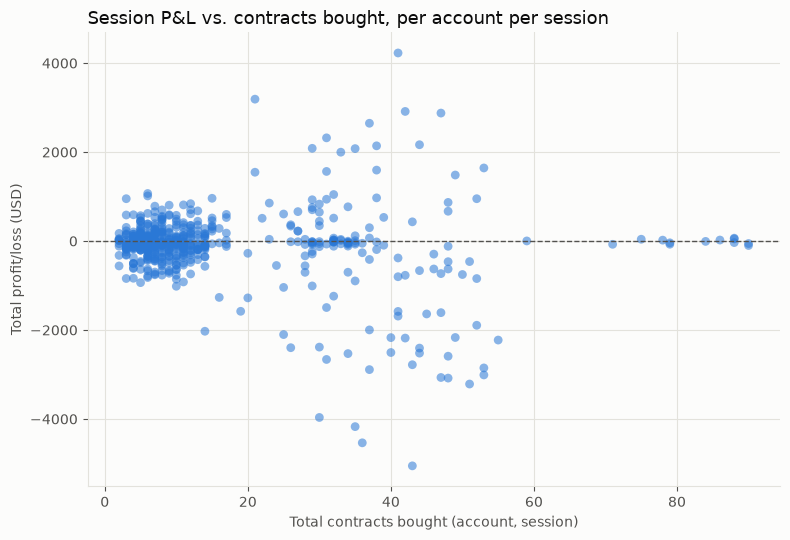

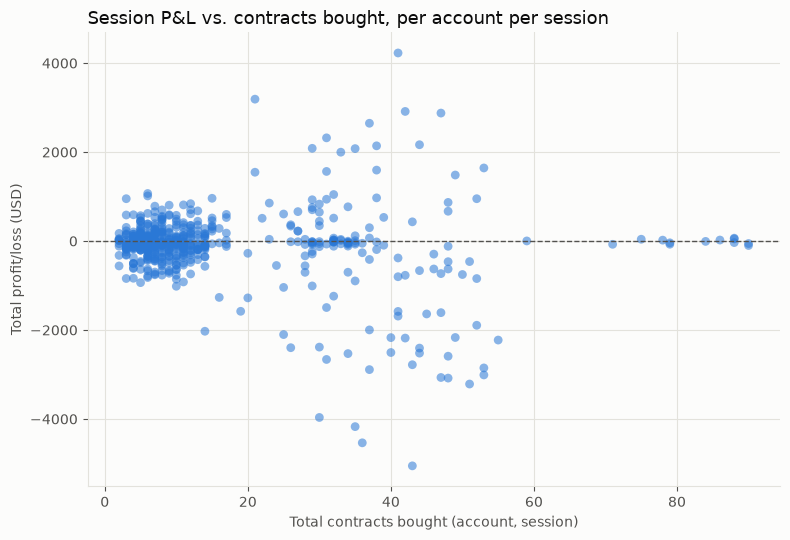

In [23]:
from trading_analysis.notebooks.session_pnl_charts import (
    aggregate_pnl_by_account_session,
    plot_pnl_against_buys,
)

account_session_pnl = aggregate_pnl_by_account_session(
    session_account_instrument_pnl
)
plot_pnl_against_buys(account_session_pnl)

In [24]:
session_account_pnl = session_account_instrument_pnl.groupby(
    ["session_date", "account_id"]
).agg(
    spent=("spent", "sum"),
    income=("income", "sum"),
    total_buys=("total_buys", "sum"),
    total_sells=("total_sells", "sum"),
    total_open=("total_open", "sum"),
    total_profit_and_loss_usd=("total_profit_and_loss_usd", "sum"),
)

session_account_pnl

spent       income  total_buys  total_sells  \
session_date account_id                                                     
2026-08-09   ACC-2001    18148755.0  18148320.00          46           46   
             ACC-2002     9815900.0   9811875.00          35           35   
             ACC-2003    16568695.0  16571785.00          42           42   
             ACC-2004     9536725.0   9534337.50          34           34   
             ACC-2005     1150490.0   1148965.00          41           41   
...                             ...          ...         ...          ...   
2026-08-24   ACC-2049     2737130.0   2737070.00          11           11   
             ACC-2050      366777.5    338491.25          13           12   
             ACC-2051      397193.5    396563.00          10           10   
             ACC-2052       96677.0     96276.00          13           13   
             ACC-2054       79222.0         0.00           2            0   

                         total_open  total_profit_and_loss_usd  
session_date account_id                                         
2026-08-09   ACC-2001             0                     -628.2  
             ACC-2002             0                    -4172.0  
             ACC-2003             0                     2913.6  
             ACC-2004             0                    -2530.3  
             ACC-2005             0                    -1582.4  
...                             ...                        ...  
2026-08-24   ACC-2049             0                     -106.2  
             ACC-2050             1                     -100.0  
             ACC-2051             0                     -644.5  
             ACC-2052             0                     -419.2  
             ACC-2054             2                       51.6  

[551 rows x 6 columns]

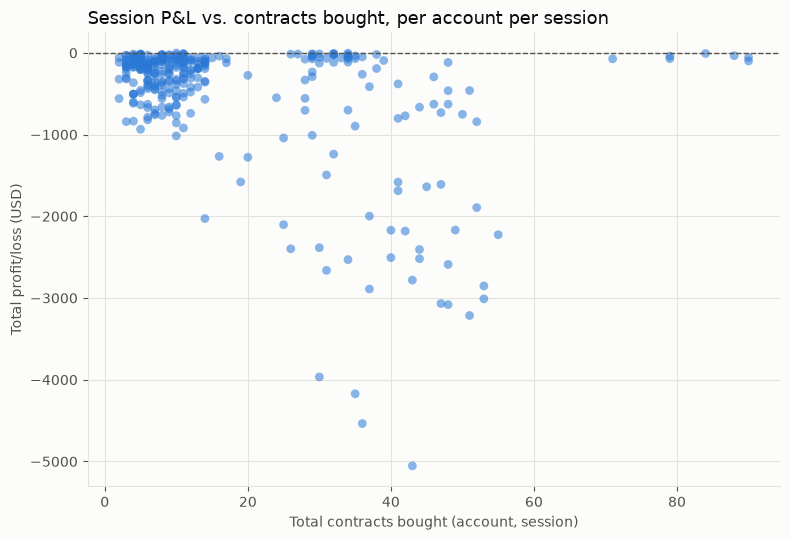

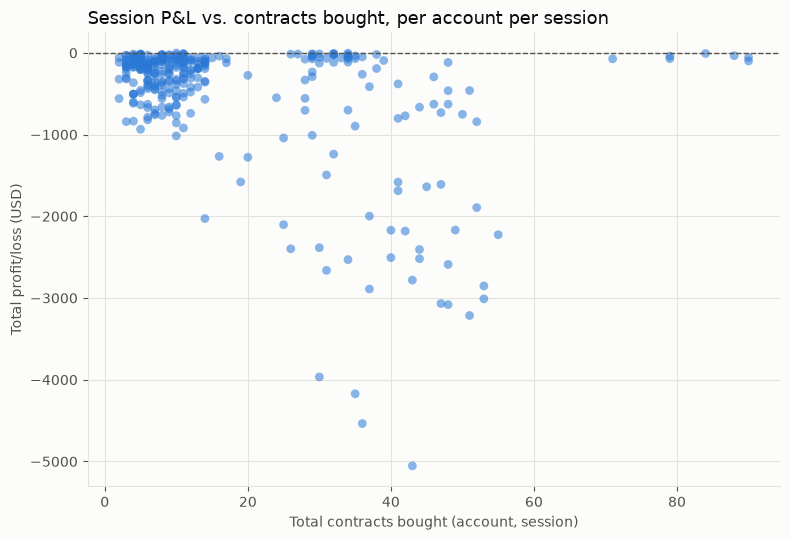

In [25]:
df = session_account_pnl[session_account_pnl["total_profit_and_loss_usd"] < 0]
plot_pnl_against_buys(df)

## 7) Merging in trader identity, and a "very bad day" rule

**Merge:** `account_session_pnl` is keyed by `account_id`, and
`traders` isn't directly joinable to it — the chain is `account_id`
→ `accounts.id` → `accounts.trader_id` → `traders.id` (the same key
established in section 2). `attach_trader_info` does that two-step
join in one call, reusing `merge_accounts_with_traders`. Verified:
every row still resolves to a trader (no row loss, no unmatched
account).

**"Very bad day" rule — judged against the account's OWN history,
not a fixed dollar amount or other accounts:**

For each account, walk its sessions in order. For every session,
build a baseline (mean, std of `total_profit_and_loss_usd`) from
only the sessions strictly *before* it — the session being judged is
never part of its own baseline. Flag it as a very bad day if it
falls more than **1.5 standard deviations below that baseline's
mean**. An account needs at least **3 prior sessions** before it can
be judged at all — with less history than that, a single bad number
isn't a meaningful baseline, so it's left unflagged rather than
guessed at.

This is a tunable default, not a fixed truth — `z_threshold` (more
negative = stricter/rarer) and `min_history_sessions` are both
parameters on `flag_bad_sessions`. Verified by hand-checking one
flagged row's mean/std/z-score against a plain pandas recomputation
of the same window — matches exactly.

In [26]:
from trading_analysis.notebooks.account_trader_merge import attach_trader_info
from trading_analysis.notebooks.bad_day_detection import flag_bad_sessions

account_session_pnl_with_traders = attach_trader_info(
    account_session_pnl, accounts, traders
)
account_session_pnl_with_traders.head()

,account_id,session_date,total_buys,total_profit_and_loss_usd,id_account,trader_id,account_number,account_type,balance,buying_power,max_position_size,status,created_at_account,id_trader,broker_id,first_name,last_name,email,phone,kyc_status,created_at_trader
0,ACC-2001,2026-08-09,46,-628.2,ACC-2001,T-001,APX-300001,eval,100000.0,100000.0,10,active,2026-03-01 00:00:00+00:00,T-001,BRK-ARWP,Mateo,Herrera,mateo.herrera@gmail.com,+1-555-0100,verified,2026-02-01 00:00:00+00:00
1,ACC-2001,2026-08-10,44,-664.8,ACC-2001,T-001,APX-300001,eval,100000.0,100000.0,10,active,2026-03-01 00:00:00+00:00,T-001,BRK-ARWP,Mateo,Herrera,mateo.herrera@gmail.com,+1-555-0100,verified,2026-02-01 00:00:00+00:00
2,ACC-2001,2026-08-11,55,-2226.0,ACC-2001,T-001,APX-300001,eval,100000.0,100000.0,10,active,2026-03-01 00:00:00+00:00,T-001,BRK-ARWP,Mateo,Herrera,mateo.herrera@gmail.com,+1-555-0100,verified,2026-02-01 00:00:00+00:00
3,ACC-2001,2026-08-12,31,2319.8,ACC-2001,T-001,APX-300001,eval,100000.0,100000.0,10,active,2026-03-01 00:00:00+00:00,T-001,BRK-ARWP,Mateo,Herrera,mateo.herrera@gmail.com,+1-555-0100,verified,2026-02-01 00:00:00+00:00
4,ACC-2001,2026-08-13,53,-3010.1,ACC-2001,T-001,APX-300001,eval,100000.0,100000.0,10,active,2026-03-01 00:00:00+00:00,T-001,BRK-ARWP,Mateo,Herrera,mateo.herrera@gmail.com,+1-555-0100,verified,2026-02-01 00:00:00+00:00


In [27]:
flagged_sessions = flag_bad_sessions(account_session_pnl)
flagged_sessions_with_traders = attach_trader_info(
    flagged_sessions, accounts, traders
)

latest_session = flagged_sessions_with_traders["session_date"].max()
having_a_very_bad_day = flagged_sessions_with_traders[
    (flagged_sessions_with_traders["session_date"] == latest_session)
    & (flagged_sessions_with_traders["is_very_bad_day"] == True)  # noqa: E712
]
having_a_very_bad_day[
    [
        "account_id",
        "first_name",
        "last_name",
        "total_profit_and_loss_usd",
        "historical_mean_pnl_usd",
        "historical_std_pnl_usd",
    ]
]

,account_id,first_name,last_name,total_profit_and_loss_usd,historical_mean_pnl_usd,historical_std_pnl_usd
83,ACC-2007,Diego,Larsen,-3067.40,64.390909,2010.292753
95,ACC-2008,Isabella,Dubois,-459.00,-29.350000,144.252941
107,ACC-2009,Santiago,Petrov,-669.95,-66.886364,115.659825
119,ACC-2010,Mariana,Okafor,-663.85,-61.331818,171.224032
131,ACC-2011,Ethan,Garcia,-758.55,8.090909,158.138495
143,ACC-2012,Olivia,Meyer,-724.10,21.868182,166.076809
155,ACC-2013,Noah,Kim,-100.00,-8.036364,47.481906
212,ACC-2018,Mia,Berg,-505.60,-33.212500,110.872578
221,ACC-2019,Mia,Berg,-505.60,-54.168750,74.226730
230,ACC-2020,Mia,Berg,-505.60,-22.762500,91.164531
